In [2]:
import zarr
import s3fs
import xarray as xr
import numpy as np
import dask.array as da

In [ ]:
eodc_s3 = s3fs.S3FileSystem(
    key="",
    secret="",
    client_kwargs={
        "endpoint_url": "https://objects.eodc.eu"
    })
zarr_stores = eodc_s3.ls("destine-climate-dt/Austria")
zarr_stores

In [6]:
SOURCE_STORES = [
    "destine-climate-dt/Austria/ICON_sfc_CMIP6_hist.zarr",
    "destine-climate-dt/Austria/ICON_sfc_ScenarioMIP_SSP3-7.0.zarr",
    "destine-climate-dt/Austria/IFS-FESOM_sfc_story-nudging_Tplus2.0K.zarr",
    "destine-climate-dt/Austria/IFS-FESOM_sfc_story-nudging_cont.zarr",
    "destine-climate-dt/Austria/IFS-FESOM_sfc_story-nudging_hist.zarr",
    "destine-climate-dt/Austria/IFS-NEMO_sfc_CMIP6_hist.zarr",
    "destine-climate-dt/Austria/IFS-NEMO_sfc_HighResMIP_cont.zarr",
    "destine-climate-dt/Austria/IFS-NEMO_sfc_ScenarioMIP_SSP3-7.0.zarr",
]
 
# FESOM stores only carry 2t; all others also have tp
FESOM_PREFIX = "ICON"
 
POINTS_CHUNKSIZE = 100
OUTPUT_STORE     = "destine-climate-dt/Austria/climate-dt-austria.zarr"
 

In [7]:
 
def get_store(path: str) -> s3fs.S3Map:
    return s3fs.S3Map(root=path, s3=eodc_s3)
 
 
def group_name_from_path(s3_path: str) -> str:
    return s3_path.rstrip("/").split("/")[-1].replace(".zarr", "")
 
 
def open_source(s3_path: str) -> xr.Dataset:
    return xr.open_zarr(get_store(s3_path))
 
 
def squeeze_and_transpose(ds: xr.Dataset) -> xr.Dataset:
    dims_to_squeeze = [d for d in ["levelist", "number", "datetime"]
                       if d in ds.dims and ds.sizes[d] == 1]
    if dims_to_squeeze:
        ds = ds.squeeze(dims_to_squeeze, drop=True)
    return ds
 
 
def variables_in_store(store_path: str, ds: xr.Dataset) -> list[str]:
    base = group_name_from_path(store_path)
    available = list(ds.data_vars)
    if FESOM_PREFIX in base:
        return [v for v in ["2t"] if v in available]
    return [v for v in ["2t", "tp"] if v in available]

In [8]:
out_store = get_store(OUTPUT_STORE)
# root = zarr.open_group(out_store, mode="w", zarr_format=3)
# print(f"Created root group at {OUTPUT_STORE}")
 

In [11]:
# ── Open one shared root store once ───────────────────────────────────────
root_store = get_store(OUTPUT_STORE)
root_group = zarr.open_group(root_store, mode="w", zarr_format=3)

for store_path in SOURCE_STORES:
    group = group_name_from_path(store_path)
    print(f"\n{'='*60}")
    print(f"Processing group : {group}")
    print(f"  Source         : {store_path}")

    # ── 1. Open source ─────────────────────────────────────────────────────
    ds_raw       = open_source(store_path)
    ds           = squeeze_and_transpose(ds_raw)
    vars_to_copy = variables_in_store(store_path, ds)

    n_points = ds.sizes["pointid"]
    n_times  = ds.sizes["t"]
    t_values = ds.coords["t"].values.astype("datetime64[s]")
    lat_vals = ds.coords["latitude"].values
    lon_vals = ds.coords["longitude"].values

    print(f"  Variables  : {vars_to_copy}")
    print(f"  Points     : {n_points}")
    print(f"  Time steps : {n_times}  ({t_values.min()} → {t_values.max()})")

    # ── 2. Build skeleton dataset ──────────────────────────────────────────
    data_arr = da.zeros(
        (n_times, n_points),
        chunks=(n_times, POINTS_CHUNKSIZE),
        dtype=np.float64,
    )

    ds_out = xr.Dataset(
        data_vars={v: (("t", "pointid"), data_arr) for v in vars_to_copy},
        coords={
            "t":         (["t"],       t_values),
            "pointid":   (["pointid"], ds.coords["pointid"].values),
            "latitude":  (["pointid"], lat_vals),
            "longitude": (["pointid"], lon_vals),
        },
    )

    encoding = {
        "t":         {"chunks": n_times},
        "pointid":   {"chunks": n_points},
        "latitude":  {"chunks": n_points},
        "longitude": {"chunks": n_points},
    }
    for v in vars_to_copy:
        encoding[v] = {"chunks": (n_times, POINTS_CHUNKSIZE)}

    # ── 3. Write skeleton — group path baked into the store ───────────────
    group_store = get_store(f"{OUTPUT_STORE}/{group}")  # <── path in the store
    print("  Writing skeleton …")
    ds_out.to_zarr(
        group_store,
        mode="w",
        compute=False,
        zarr_format=3,
        encoding=encoding,
    )

    # ── 4. Fill with actual data ───────────────────────────────────────────
    print("  Filling data …")
    dtcube = zarr.open_group(group_store, mode="a", zarr_format=3)

    for v in vars_to_copy:
        data = ds[v].transpose("t", "pointid").values
        dtcube[v][:, :] = data
        print(f"    ✓ {v}  shape={data.shape}")

    print(f"  Done → {OUTPUT_STORE}/{group}")

# ── Consolidate metadata into root zarr.json for HTTP access ──────────────
print("\nConsolidating metadata …")
zarr.consolidate_metadata(root_store)
print("All done.")


Processing group : ICON_sfc_CMIP6_hist
  Source         : destine-climate-dt/Austria/ICON_sfc_CMIP6_hist.zarr
  Variables  : ['2t']
  Points     : 2009
  Time steps : 252792  (1991-03-01T00:00:00 → 2019-12-31T23:00:00)
  Writing skeleton …


/home/koenifra/.venvs/s3_access/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


  Filling data …
    ✓ 2t  shape=(252792, 2009)
  Done → destine-climate-dt/Austria/climate-dt-austria.zarr/ICON_sfc_CMIP6_hist

Processing group : ICON_sfc_ScenarioMIP_SSP3-7.0
  Source         : destine-climate-dt/Austria/ICON_sfc_ScenarioMIP_SSP3-7.0.zarr
  Variables  : ['2t']
  Points     : 2079
  Time steps : 169464  (2020-09-01T00:00:00 → 2039-12-31T23:00:00)
  Writing skeleton …


/home/koenifra/.venvs/s3_access/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


  Filling data …
    ✓ 2t  shape=(169464, 2079)
  Done → destine-climate-dt/Austria/climate-dt-austria.zarr/ICON_sfc_ScenarioMIP_SSP3-7.0

Processing group : IFS-FESOM_sfc_story-nudging_Tplus2.0K
  Source         : destine-climate-dt/Austria/IFS-FESOM_sfc_story-nudging_Tplus2.0K.zarr
  Variables  : ['2t', 'tp']
  Points     : 517
  Time steps : 61344  (2017-01-01T00:00:00 → 2023-12-31T23:00:00)
  Writing skeleton …


...

/home/koenifra/.venvs/s3_access/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


  Filling data …
    ✓ 2t  shape=(151896, 2013)
    ✓ tp  shape=(151896, 2013)
  Done → destine-climate-dt/Austria/climate-dt-austria.zarr/IFS-NEMO_sfc_HighResMIP_cont

Processing group : IFS-NEMO_sfc_ScenarioMIP_SSP3-7.0
  Source         : destine-climate-dt/Austria/IFS-NEMO_sfc_ScenarioMIP_SSP3-7.0.zarr
  Variables  : ['2t', 'tp']
  Points     : 2067
  Time steps : 175320  (2020-01-01T00:00:00 → 2039-12-31T23:00:00)
  Writing skeleton …


/home/koenifra/.venvs/s3_access/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


  Filling data …
    ✓ 2t  shape=(175320, 2067)
    ✓ tp  shape=(175320, 2067)
  Done → destine-climate-dt/Austria/climate-dt-austria.zarr/IFS-NEMO_sfc_ScenarioMIP_SSP3-7.0

Consolidating metadata …
All done.


/home/koenifra/.venvs/s3_access/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [35]:
store = zarr.open(out_store, mode="r")
print(store.tree())

/
├── ICON_sfc_CMIP6_hist
│   ├── 2t (252792, 2009) float64
│   ├── latitude (2009,) float64
│   ├── longitude (2009,) float64
│   ├── pointid (2009,) int64
│   └── t (252792,) int64
├── ICON_sfc_ScenarioMIP_SSP3-7.0
│   ├── 2t (169464, 2079) float64
│   ├── latitude (2079,) float64
│   ├── longitude (2079,) float64
│   ├── pointid (2079,) int64
│   └── t (169464,) int64
├── IFS-FESOM_sfc_story-nudging_Tplus2.0K
│   ├── 2t (61344, 517) float64
│   ├── latitude (517,) float64
│   ├── longitude (517,) float64
│   ├── pointid (517,) int64
│   ├── t (61344,) int64
│   └── tp (61344, 517) float64
├── IFS-FESOM_sfc_story-nudging_cont
│   ├── 2t (61344, 2063) float64
│   ├── latitude (2063,) float64
│   ├── longitude (2063,) float64
│   ├── pointid (2063,) int64
│   ├── t (61344,) int64
│   └── tp (61344, 2063) float64
├── IFS-FESOM_sfc_story-nudging_hist
│   ├── 2t (61344, 516) float64
│   ├── latitude (516,) float64
│   ├── longitude (516,) float64
│   ├── pointid (516,) int64
│   ├── t (61344,) int64
│   └── tp (61344, 516) float64
├── IFS-NEMO_sfc_CMIP6_hist
│   ├── 2t (105192, 2067) float64
│   ├── latitude (2067,) float64
│   ├── longitude (2067,) float64
│   ├── pointid (2067,) int64
│   ├── t (105192,) int64
│   └── tp (105192, 2067) float64
├── IFS-NEMO_sfc_HighResMIP_cont
│   ├── 2t (151896, 2013) float64
│   ├── latitude (2013,) float64
│   ├── longitude (2013,) float64
│   ├── pointid (2013,) int64
│   ├── t (151896,) int64
│   └── tp (151896, 2013) float64
└── IFS-NEMO_sfc_ScenarioMIP_SSP3-7.0
    ├── 2t (175320, 2067) float64
    ├── latitude (2067,) float64
    ├── longitude (2067,) float64
    ├── pointid (2067,) int64
    ├── t (175320,) int64
    └── tp (175320, 2067) float64

In [36]:
out_store

/tmp/ipykernel_244964/1673275238.py:1: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  zstore_timedim = xr.open_zarr(
/tmp/ipykernel_244964/1673275238.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "pointid" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  zstore_timedim = xr.open_zarr(


<xarray.Dataset> Size: 3GB
Dimensions:    (t: 169464, pointid: 2079)
Coordinates:
  * t          (t) datetime64[ns] 1MB 2020-09-01 ... 2039-12-31T23:00:00
  * pointid    (pointid) int64 17kB 1 0 2 3 4 7 5 11 ... 3 11 16 24 13 26 25 27
    latitude   (pointid) float64 17kB dask.array<chunksize=(2079,), meta=np.ndarray>
    longitude  (pointid) float64 17kB dask.array<chunksize=(2079,), meta=np.ndarray>
Data variables:
    2t         (t, pointid) float64 3GB dask.array<chunksize=(169464, 1), meta=np.ndarray>


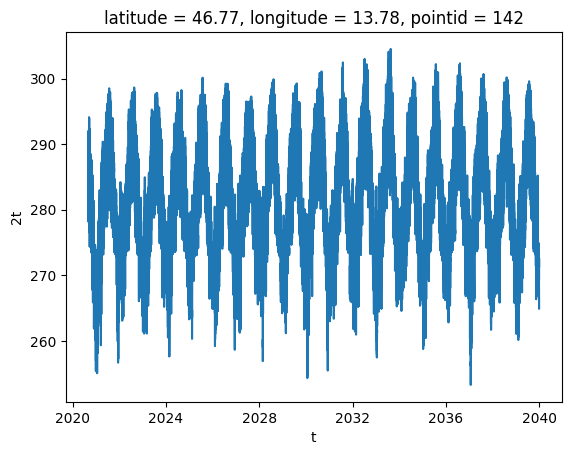

In [34]:
zstore_timedim = xr.open_zarr(
    out_store,
    group="ICON_sfc_ScenarioMIP_SSP3-7.0",
    chunks="auto",
    zarr_format=3
)

print(zstore_timedim)
zstore_timedim["2t"].isel(pointid=142).plot()

<xarray.Dataset> Size: 3GB
Dimensions:    (pointid: 2079, levelist: 1, number: 1, datetime: 1, t: 169464)
Coordinates:
  * pointid    (pointid) int64 17kB 1 0 2 3 4 7 5 11 ... 3 11 16 24 13 26 25 27
    latitude   (pointid) float64 17kB dask.array<chunksize=(2079,), meta=np.ndarray>
    longitude  (pointid) float64 17kB dask.array<chunksize=(2079,), meta=np.ndarray>
  * levelist   (levelist) int64 8B 0
  * number     (number) int64 8B 0
  * datetime   (datetime) <U20 80B '2039-12-31 00:00:00Z'
  * t          (t) datetime64[ns] 1MB 2020-09-01 ... 2039-12-31T23:00:00
Data variables:
    2t         (pointid, levelist, number, datetime, t) float64 3GB dask.array<chunksize=(99, 1, 1, 1, 169464), meta=np.ndarray>
Attributes: (12/14)
    activity:       scenariomip
    class:          d1
    dataset:        climate-dt
    experiment:     ssp3-7.0
    expver:         0001
    generation:     1
    ...             ...
    realization:    1
    resolution:     high
    stream:         clte
    t

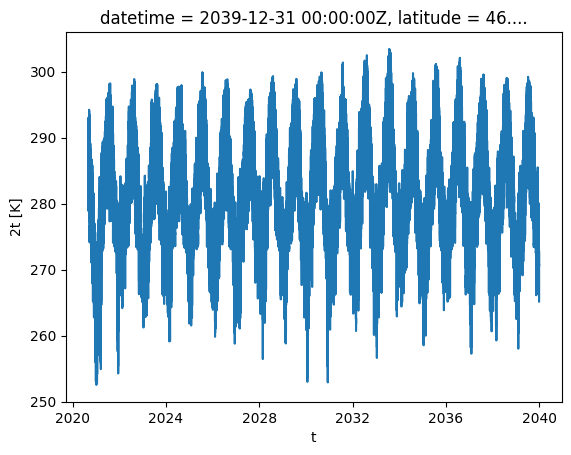

In [33]:
out2_store = get_store("destine-climate-dt/Austria/ICON_sfc_ScenarioMIP_SSP3-7.0.zarr")

zstore_timedim2 = xr.open_zarr(
    out2_store,
    chunks="auto",
    zarr_format=3
)

print(zstore_timedim2)
zstore_timedim2["2t"].isel(pointid=102).plot()

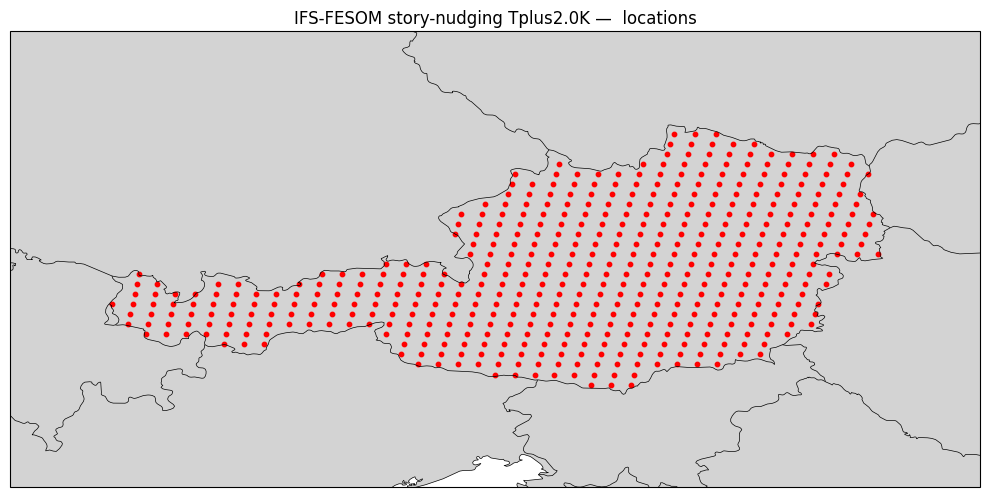

In [39]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

ds = xr.open_zarr(get_store(f"{OUTPUT_STORE}/IFS-FESOM_sfc_story-nudging_Tplus2.0K"), zarr_format=3)

lats = ds.coords["latitude"].values
lons = ds.coords["longitude"].values

fig, ax = plt.subplots(figsize=(10, 7),
                       subplot_kw={"projection": ccrs.PlateCarree()})

ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgray")

ax.scatter(lons, lats, s=10, c="red", transform=ccrs.PlateCarree())

ax.set_extent([lons.min()-1, lons.max()+1, lats.min()-1, lats.max()+1],
              crs=ccrs.PlateCarree())

plt.title("IFS-FESOM story-nudging Tplus2.0K —  locations")
plt.tight_layout()
plt.show()

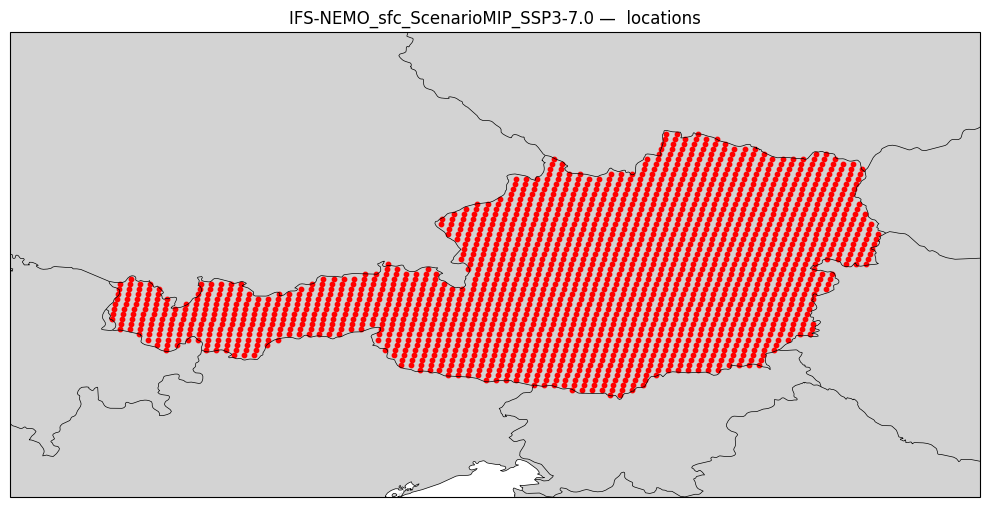

In [38]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

ds = xr.open_zarr(get_store(f"{OUTPUT_STORE}/IFS-NEMO_sfc_ScenarioMIP_SSP3-7.0"), zarr_format=3)

lats = ds.coords["latitude"].values
lons = ds.coords["longitude"].values

fig, ax = plt.subplots(figsize=(10, 7),
                       subplot_kw={"projection": ccrs.PlateCarree()})

ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgray")

ax.scatter(lons, lats, s=10, c="red", transform=ccrs.PlateCarree())

ax.set_extent([lons.min()-1, lons.max()+1, lats.min()-1, lats.max()+1],
              crs=ccrs.PlateCarree())

plt.title("IFS-NEMO_sfc_ScenarioMIP_SSP3-7.0 —  locations")
plt.tight_layout()
plt.show()